In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_stock_data .csv')

In [3]:
# DISCRIPTIVE STATS

In [4]:
df.head()

,Date,Open,Stock_Name,High,Low,Close,Adj_Close,Volume
0,2021-07-06,140.07,AAPL,143.15,140.07,142.02,138.43428,108181800
1,2021-07-06,278.03,MSFT,279.37,274.30,277.66,266.46936,31565600
2,2021-07-06,433.78,SPY,434.01,430.01,432.93,404.62964,68710400
3,2021-07-07,143.54,AAPL,144.89,142.66,144.57,140.91990,104911600
4,2021-07-07,279.40,MSFT,280.69,277.15,279.93,268.64790,23260000


In [5]:
df.shape

(3762, 8)

In [6]:
df.columns

Index(['Date', 'Open', 'Stock_Name', 'High', 'Low', 'Close', 'Adj_Close',
       'Volume'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        3762 non-null   object 
 1   Open        3762 non-null   float64
 2   Stock_Name  3762 non-null   object 
 3   High        3762 non-null   float64
 4   Low         3762 non-null   float64
 5   Close       3762 non-null   float64
 6   Adj_Close   3762 non-null   float64
 7   Volume      3762 non-null   int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 235.3+ KB


In [8]:
df.describe()

,Open,High,Low,Close,Adj_Close,Volume
count,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3.762000e+03
mean,358.628365,361.439091,355.724793,358.726874,350.973041,5.586439e+07
std,153.544588,153.882828,152.971505,153.489382,151.100421,3.245029e+07
min,126.010000,127.770000,124.170000,125.020000,122.933540,5.855900e+06
25%,227.347500,229.582500,225.380000,227.527500,225.401705,2.998885e+07
50%,368.970000,373.040000,364.695000,368.685000,356.570235,5.023690e+07
75%,450.730000,452.977500,448.727500,450.892500,434.204850,7.406888e+07
max,758.150000,760.400000,756.750000,759.570000,757.618200,3.186799e+08


In [9]:
df['Close'].std()

153.4893816621203

In [10]:
df['Close'].median()

368.685

In [11]:
stock_summary = df.groupby("Stock_Name")[["Open", "High", "Low", "Close", "Volume"]].agg(
    ["mean", "median", "std", "min", "max"]
)

stock_summary

Open                                            High  \
                  mean  median         std     min     max        mean   
Stock_Name                                                               
AAPL        195.776882  184.90   44.011753  126.01  314.18  197.933596   
MSFT        365.417648  371.53   81.801343  217.55  555.23  368.831922   
SPY         514.690566  475.35  105.708127  349.21  758.15  517.551754   

                                                 ...       Close           \
             median         std     min     max  ...        mean   median   
Stock_Name                                       ...                        
AAPL        186.655   44.389882  127.77  317.40  ...  195.971962  184.965   
MSFT        374.440   81.980070  220.41  555.45  ...  365.405231  371.950   
SPY         477.045  105.762394  359.82  760.40  ...  514.803429  475.905   

                                              Volume              \
                   std     min     max          mean      median   
Stock_Name                                                         
AAPL         44.017036  125.02  315.20  6.530999e+07  57286200.0   
MSFT         81.678757  214.25  542.07  2.657134e+07  23645300.0   
SPY         105.694776  356.56  759.57  7.571184e+07  71205850.0   

                                               
                     std       min        max  
Stock_Name                                     
AAPL        2.874114e+07  17910600  318679900  
MSFT        1.206951e+07   5855900  186201600  
SPY         2.909854e+07  26048700  256611400  

[3 rows x 25 columns]

In [12]:
df.groupby('Stock_Name')['Close'].mean()

,Close
Stock_Name,
AAPL,195.971962
MSFT,365.405231
SPY,514.803429


In [13]:
df.groupby('Stock_Name')['Close'].median()

,Close
Stock_Name,
AAPL,184.965
MSFT,371.950
SPY,475.905


In [14]:
df.groupby('Stock_Name')['Close'].std()

,Close
Stock_Name,
AAPL,44.017036
MSFT,81.678757
SPY,105.694776


In [15]:
df.groupby('Stock_Name')['Close'].var()

,Close
Stock_Name,
AAPL,1937.499486
MSFT,6671.419368
SPY,11171.385734


In [16]:
df.groupby('Stock_Name')['Close'].skew()

,Close
Stock_Name,
AAPL,0.598866
MSFT,0.131153
SPY,0.534675


In [17]:
df.groupby('Stock_Name')['Close'].apply(pd.Series.kurt)

,Close
Stock_Name,
AAPL,-0.623319
MSFT,-1.036238
SPY,-0.938773


In [18]:
# DISTRIBUTION ANALYSiS

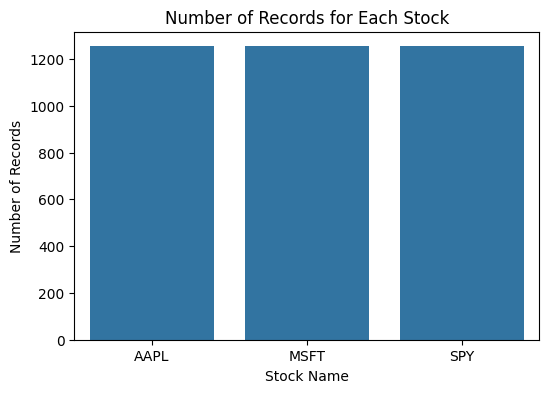

In [19]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Stock_Name')
plt.title("Number of Records for Each Stock")
plt.xlabel("Stock Name")
plt.ylabel("Number of Records")
plt.show()

In [20]:
# shows the no. of records available for each stock
#equal no. of observation which indicates that the dataset is balanced


# KEY INSIGHT - The equal distribution of records means  that no stock is overrepresented which  makes
#  subsequent statistical analysis and comparisons more reliable.

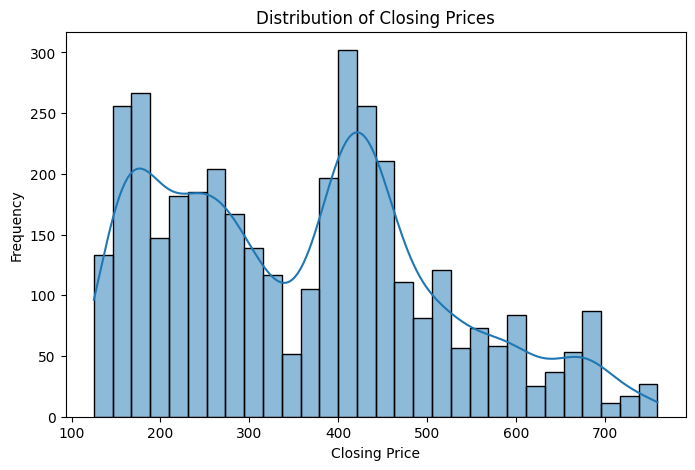

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], bins=30, kde=True)
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

In [22]:
# KEY INSIGHT - The distribution of closing prices helps in understanding the typical trading range and
# detecting any unusual concentration of prices or extreme values.

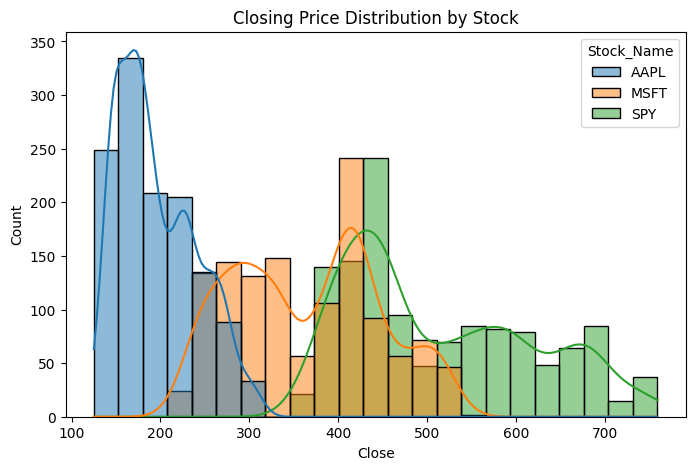

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Close', hue='Stock_Name', kde=True)
plt.title("Closing Price Distribution by Stock")
plt.show()

In [24]:
#comapring the closing price distribution of apple, microsoft,SPY
# highlights differences in their typical trading price ranges and the spread of prices.
# The overlapping distributions help identify similarities and differences among the stocks.


# KEY INSIGHT - Comparing price distributions provides a better understanding of each stock's typical market value and pricing behavior

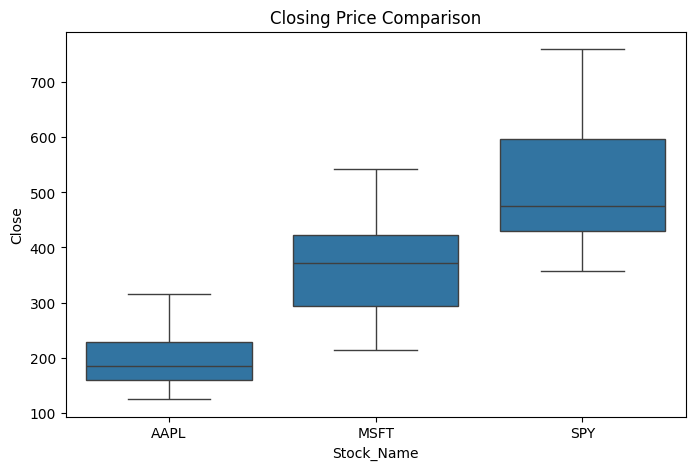

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Stock_Name', y='Close')
plt.title("Closing Price Comparison")
plt.show()

In [26]:
# boxplot shows median , quartiles for each stock
# it helps compare the variablity of closing price across all stocks
# outliers indicates trading days where prices were unsually low or high


#KEY INSIGHT - The stock with the widest box and whiskers shows greater price variability, while a narrower box indicates more stable price movements.

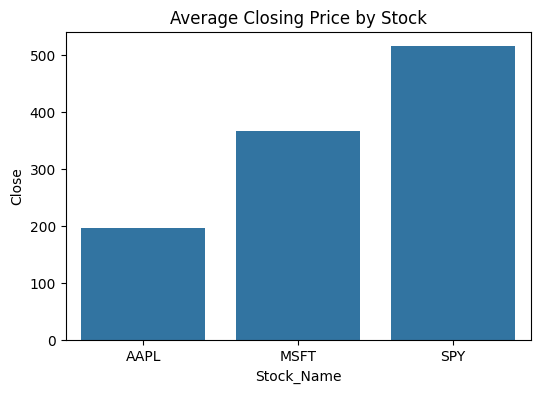

In [27]:
avg_close = df.groupby('Stock_Name')['Close'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_close, x='Stock_Name', y='Close')
plt.title("Average Closing Price by Stock")
plt.show()

In [28]:
# the bar chart compares avg closing price of apple,microsoft and SPY
# overview of which stock maintain high avg price in market

#KEY INSIGHT - The stock with the highest average closing price maintained the strongest average market valuation

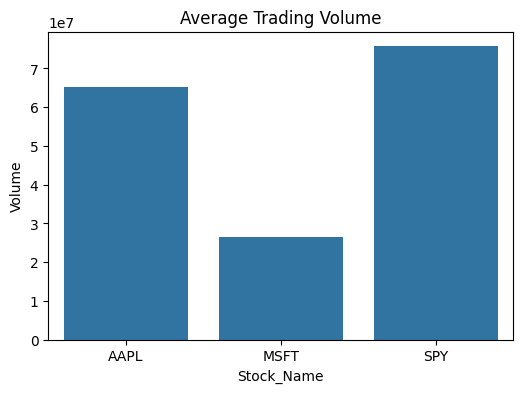

In [29]:
avg_volume = df.groupby('Stock_Name')['Volume'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_volume, x='Stock_Name', y='Volume')
plt.title("Average Trading Volume")
plt.show()

In [30]:
# compares the avg no. of shares traded for each stock
# higher trading volumne indicates greater investor participation and market activity


#KEY INSIGHT - stocks with higher avg trading volume have greater liquidity ,  easier to buy and sell in the market

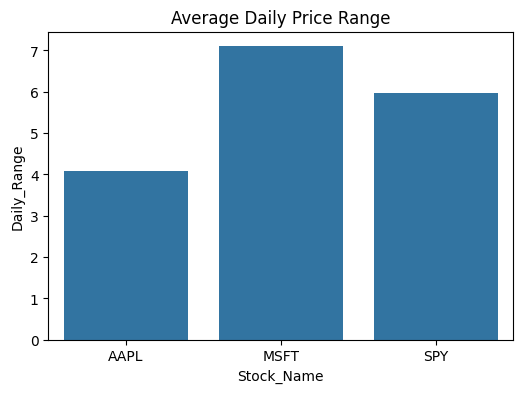

In [31]:
df['Daily_Range'] = df['High'] - df['Low']

daily_range = df.groupby('Stock_Name')['Daily_Range'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=daily_range, x='Stock_Name', y='Daily_Range')
plt.title("Average Daily Price Range")
plt.show()

In [32]:
# the daily price range measure the diff b/w highest & lowest price during a trading day
# chart compares avg daily price of all three stocks
#larger daily ranges indicates greater price fluctuation within a single trading day

# KEY INSIGHT - This chart shows how much each stock's price changes in a single day.
# A larger daily range means bigger price movements, while a smaller range indicates more stable prices.

In [33]:
# COORELATION ANALYSIS

In [34]:
pivot = df.pivot_table(index='Date', columns='Stock_Name', values='Close')

pivot.head()

Stock_Name,AAPL,MSFT,SPY
Date,,,
2021-07-06,142.02,277.66,432.93
2021-07-07,144.57,279.93,434.46
2021-07-08,143.24,277.42,430.92
2021-07-09,145.11,277.94,435.52
2021-07-12,144.50,277.32,437.08


In [35]:
corr_matrix = pivot.corr()

corr_matrix

Stock_Name,AAPL,MSFT,SPY
Stock_Name,,,
AAPL,1.000000,0.787949,0.947195
MSFT,0.787949,1.000000,0.853247
SPY,0.947195,0.853247,1.000000


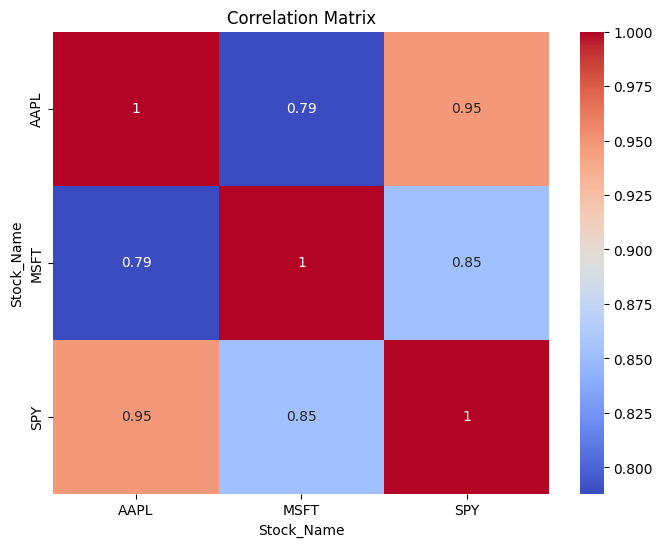

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [37]:
# relationship between the closing prices of Apple, Microsoft, and SPY.
# heatmap shows the correlation coefficients between the closing prices of the three stocks
# ~1 strong +ve relationship , ~0 weak relationship


#these relationships can help investors to analyze market behaviour

In [38]:
# TREND ANALYSIS

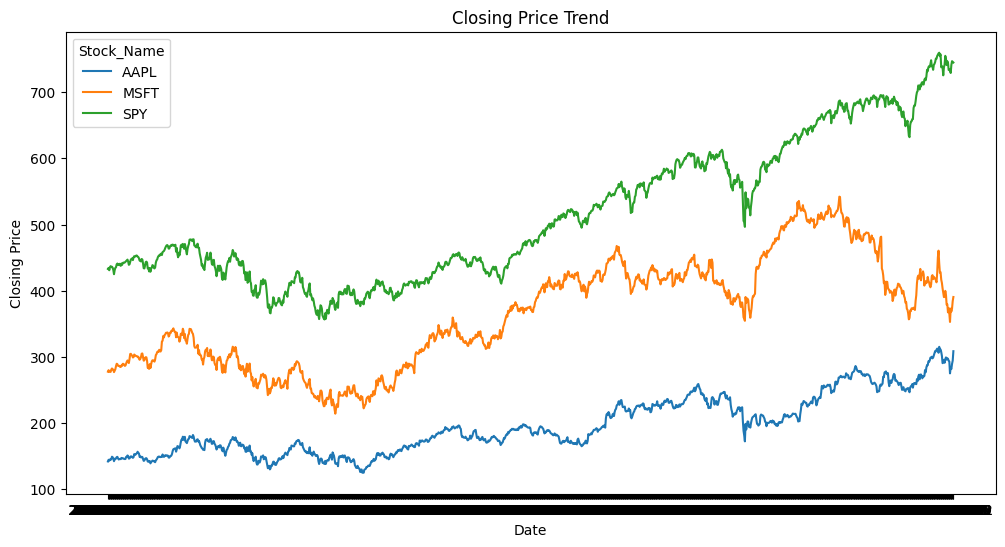

In [39]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Close', hue='Stock_Name')
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [40]:
# large fluctuation shows higher volatility

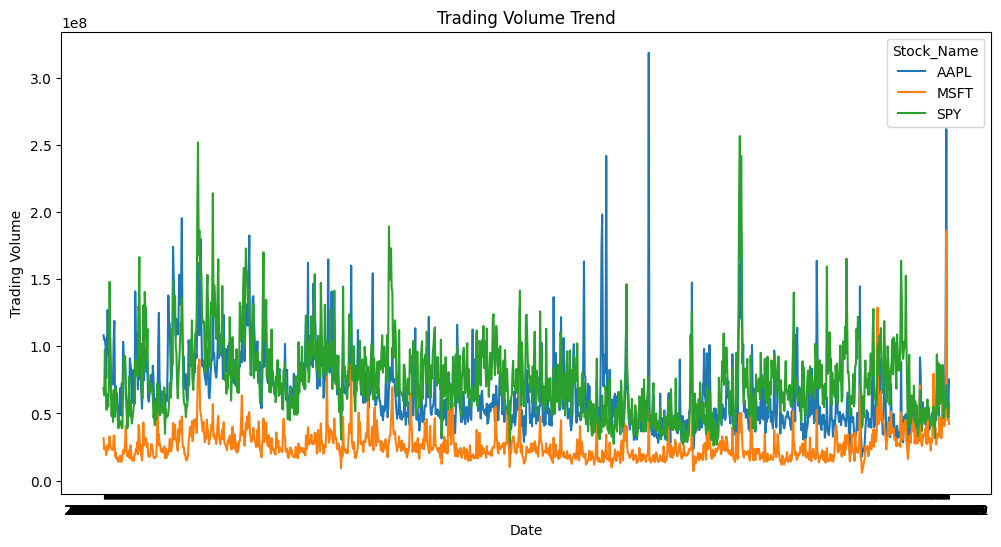

In [41]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Volume', hue='Stock_Name')
plt.title("Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.show()

In [42]:
# chart shows daily trading volume for each stock ,
# Peaks represent periods of increased buying and selling activity

#KEY INSIGHT - Higher trading volume  reflects greater investor interest

Text(0, 0.5, 'Daily Price Range')

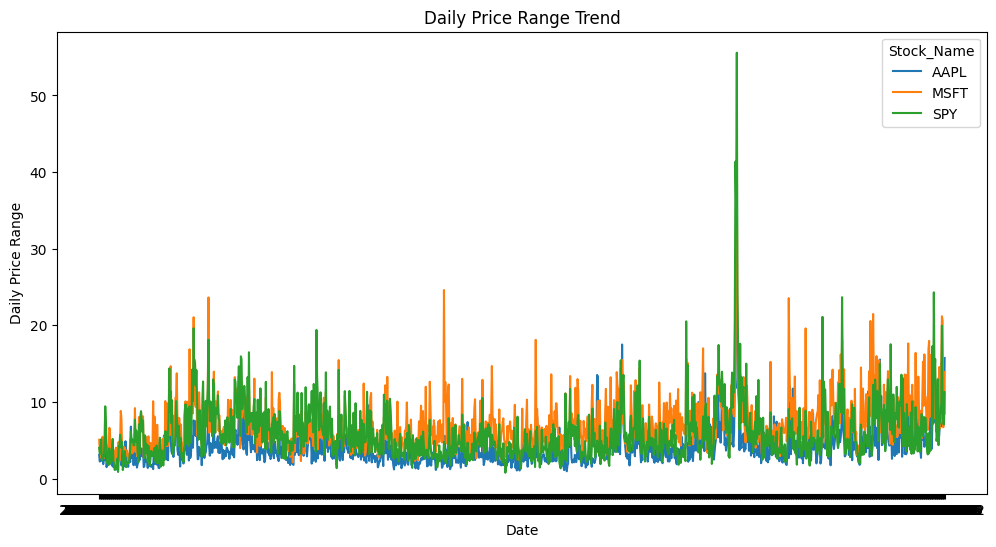

In [43]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Daily_Range', hue='Stock_Name')
plt.title("Daily Price Range Trend")
plt.xlabel("Date")
plt.ylabel("Daily Price Range")

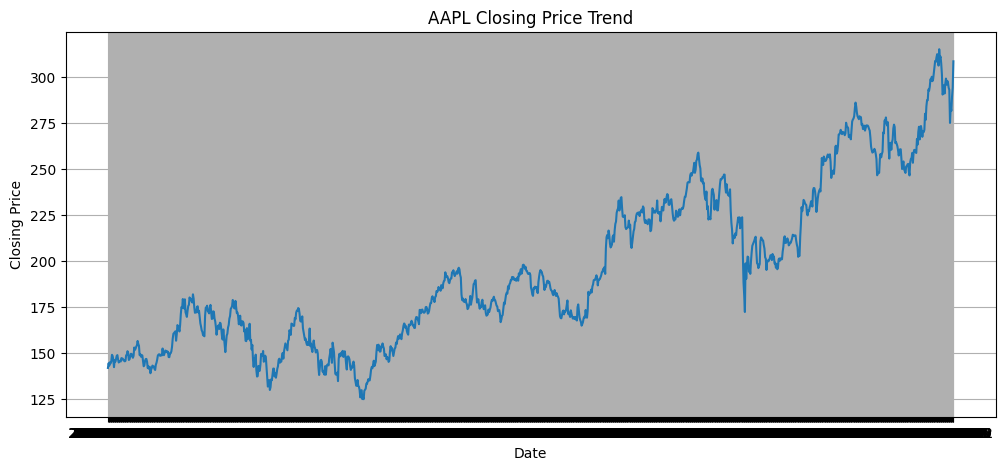

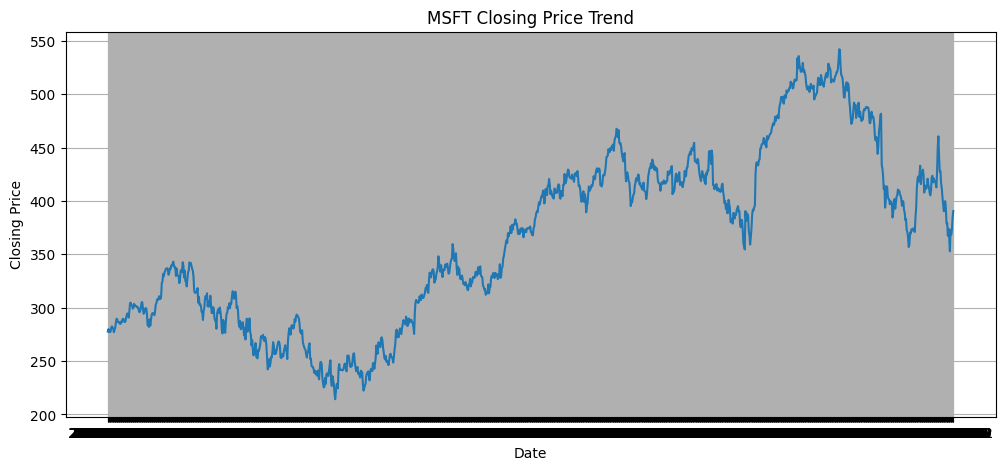

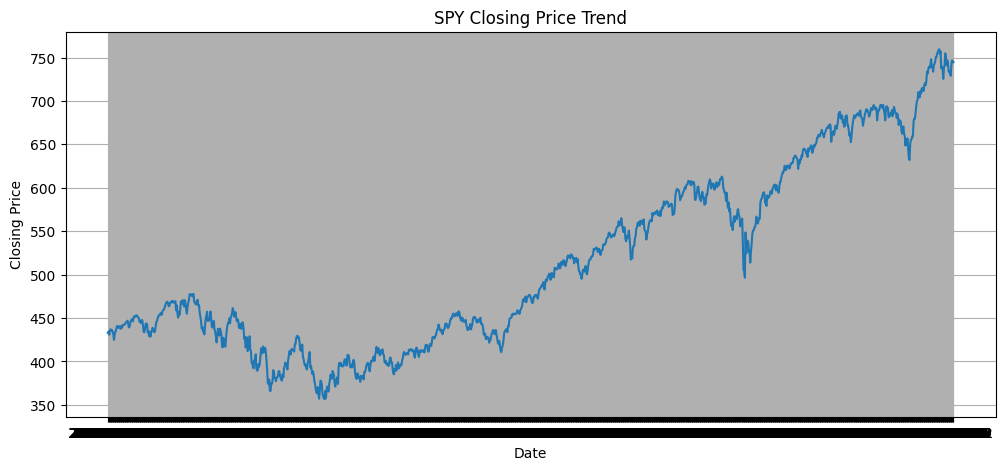

In [44]:
stocks = df['Stock_Name'].unique()
for stock in stocks:
  plt.figure(figsize=(12,5))
  temp = df[df['Stock_Name'] == stock]
  plt.plot(temp['Date'], temp['Close'])
  plt.title(f"{stock} Closing Price Trend")
  plt.xlabel("Date")
  plt.ylabel("Closing Price")
  plt.grid(True)
  plt.show()

In [45]:
# MOVING AVG ANALYSIS


In [46]:
stocks = df['Stock_Name'].unique()

for stock in stocks:
    df.loc[df['Stock_Name'] == stock, 'MA20'] = (
        df[df['Stock_Name'] == stock]['Close']
        .rolling(window=20)
        .mean()
    )

In [47]:
df.head(24)

,Date,Open,Stock_Name,High,Low,Close,Adj_Close,Volume,Daily_Range,MA20
0,2021-07-06,140.07,AAPL,143.15,140.07,142.02,138.43428,108181800,3.08,NaN
1,2021-07-06,278.03,MSFT,279.37,274.30,277.66,266.46936,31565600,5.07,NaN
2,2021-07-06,433.78,SPY,434.01,430.01,432.93,404.62964,68710400,4.00,NaN
3,2021-07-07,143.54,AAPL,144.89,142.66,144.57,140.91990,104911600,2.23,NaN
4,2021-07-07,279.40,MSFT,280.69,277.15,279.93,268.64790,23260000,3.54,NaN
5,2021-07-07,433.66,SPY,434.76,431.51,434.46,406.05966,63549500,3.25,NaN
6,2021-07-08,141.58,AAPL,144.06,140.67,143.24,139.62346,105575500,3.39,NaN
7,2021-07-08,276.90,MSFT,278.73,274.87,277.42,266.23910,24618600,3.86,NaN
8,2021-07-08,428.78,SPY,431.73,427.52,430.92,402.75110,97595200,4.21,NaN
9,2021-07-09,142.75,AAPL,145.65,142.65,145.11,141.44623,99890800,3.00,NaN


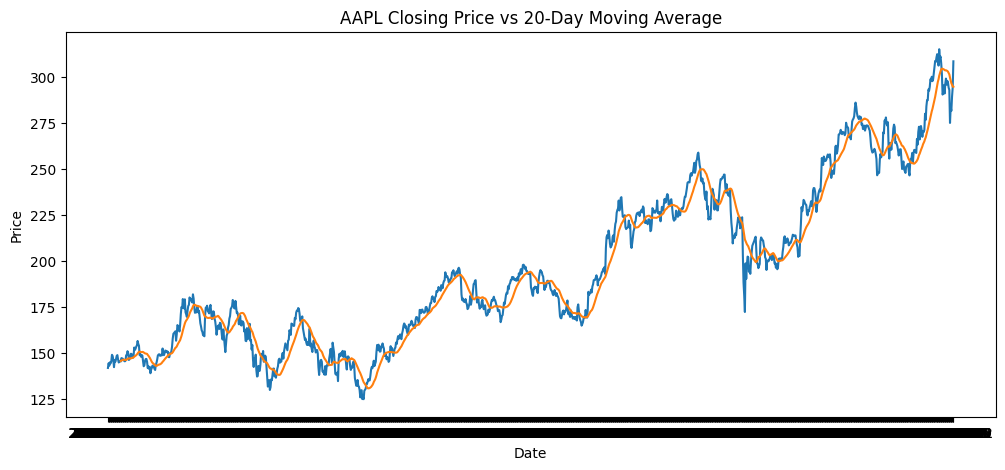

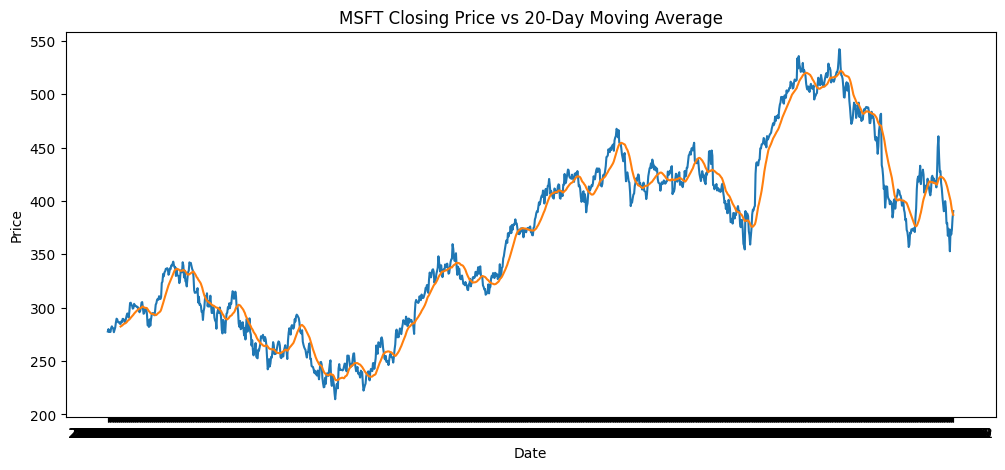

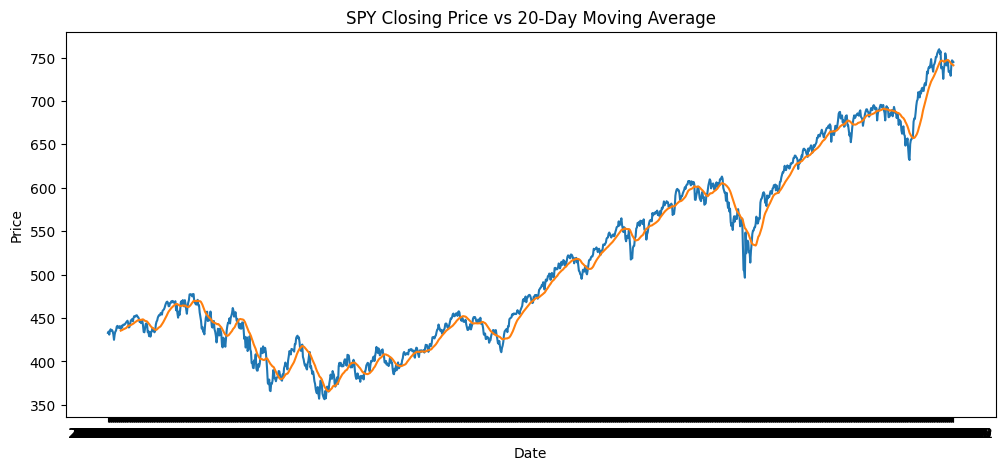

In [48]:
for stock in stocks:

    temp = df[df['Stock_Name'] == stock]

    plt.figure(figsize=(12,5))

    plt.plot(temp['Date'], temp['Close'], label='Closing Price')

    plt.plot(temp['Date'], temp['MA20'], label='20-Day MA')

    plt.title(f"{stock} Closing Price vs 20-Day Moving Average")

    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.show()

In [49]:
#compare the daily closing price with its 20-day moving average and
#identify the overall trend by reducing short-term price fluctuations.


#When the closing price stays above the moving average, it generally indicates an upward trend,
#When it remains below the moving average, it may indicate a downward trend.

In [50]:
for stock in stocks:
    df.loc[df['Stock_Name'] == stock, 'MA50'] = (
        df[df['Stock_Name'] == stock]['Close']
        .rolling(window=50)
        .mean()
    )

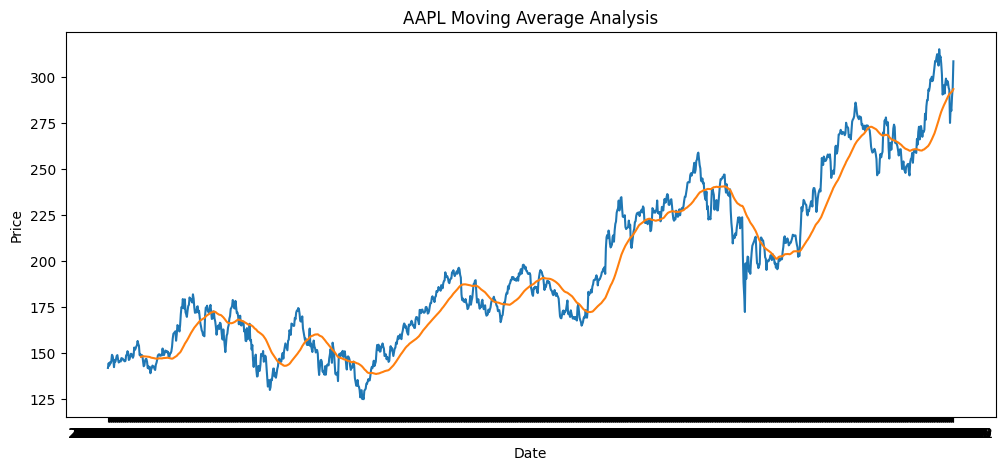

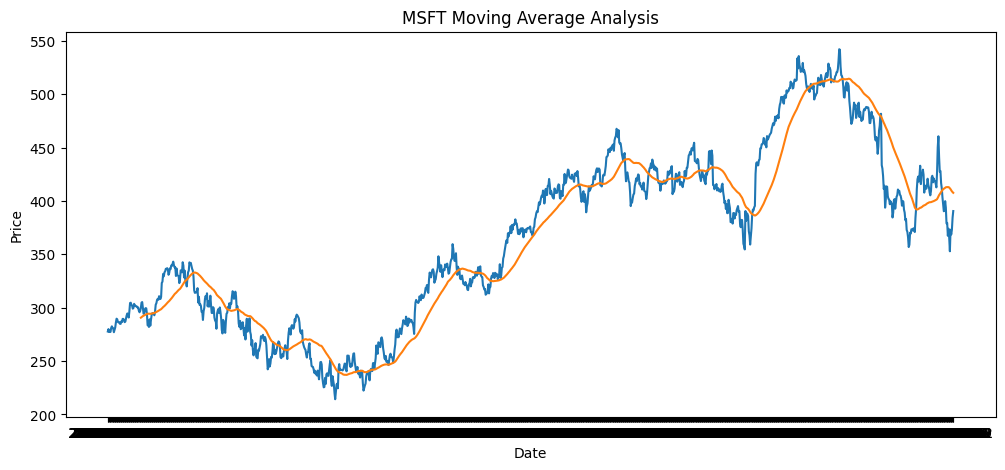

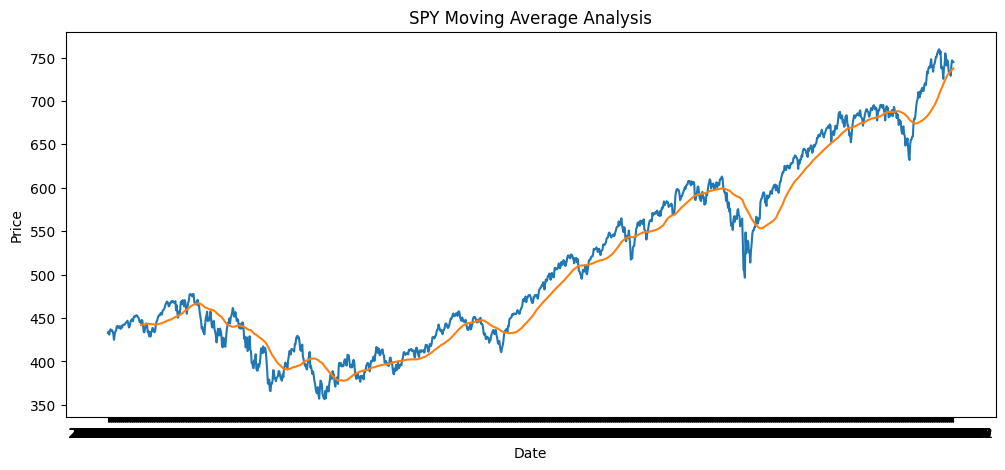

In [51]:
for stock in stocks:

    temp = df[df['Stock_Name'] == stock]

    plt.figure(figsize=(12,5))

    plt.plot(temp['Date'], temp['Close'], label='Close')

    # plt.plot(temp['Date'], temp['MA20'], label='20-Day MA')

    plt.plot(temp['Date'], temp['MA50'], label='50-Day MA')

    plt.title(f"{stock} Moving Average Analysis")

    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.show()

In [52]:
df['Date'].dtype

dtype('O')

In [53]:
df['Date'] = pd.to_datetime(df['Date'])

In [54]:
df['Date'].dtype

dtype('<M8[ns]')

In [55]:
df['Month'] = df['Date'].dt.month_name()

In [56]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

/tmp/ipykernel_1204/1139692805.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Month','Stock_Name'])['Close']


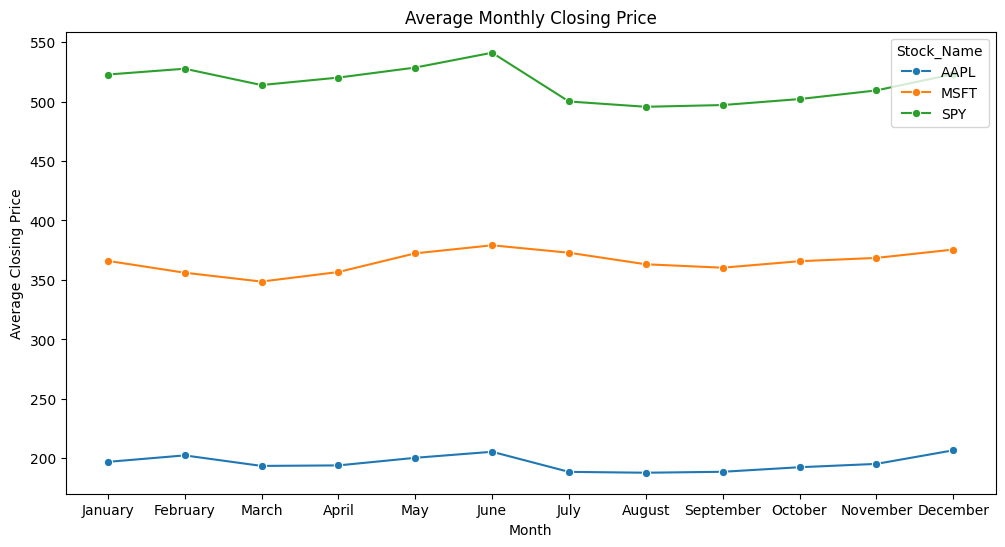

In [57]:
monthly_close = (
    df.groupby(['Month','Stock_Name'])['Close']
      .mean()
      .reset_index()
)
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_close,
    x='Month',
    y='Close',
    hue='Stock_Name',
    marker='o'
)
plt.title("Average Monthly Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.show()

In [58]:
# The line chart compares the average closing prices of different months for all three stocks.
#It highlights months with relatively higher or lower average prices and helps identify seasonal patterns.


#Monthly average prices help identify periods where stocks performed relatively better or weaker during the year.

/tmp/ipykernel_1204/954396168.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Month','Stock_Name'])['Volume']


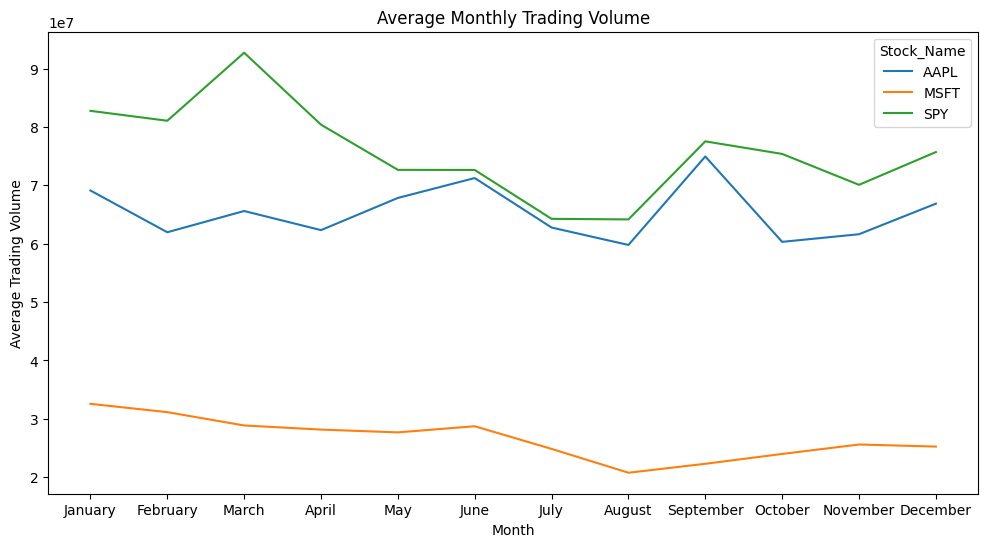

In [59]:
monthly_volume = (
    df.groupby(['Month','Stock_Name'])['Volume']
      .mean()
      .reset_index()
)
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_volume,
    x='Month',
    y='Volume',
    hue='Stock_Name')
plt.title("Average Monthly Trading Volume")
plt.xlabel("Month")
plt.ylabel("Average Trading Volume")
plt.show()

In [60]:
# chart compares the average monthly trading volume for each stock.
#Higher values indicate months with greater investor participation and trading activity

#Months with higher trading volume generally reflect increased market activity and investor interest

In [61]:
df['Daily_Return'] = (
    df.groupby('Stock_Name')['Close']
      .pct_change()
)

/tmp/ipykernel_1204/805018741.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Month','Stock_Name'])['Daily_Return']


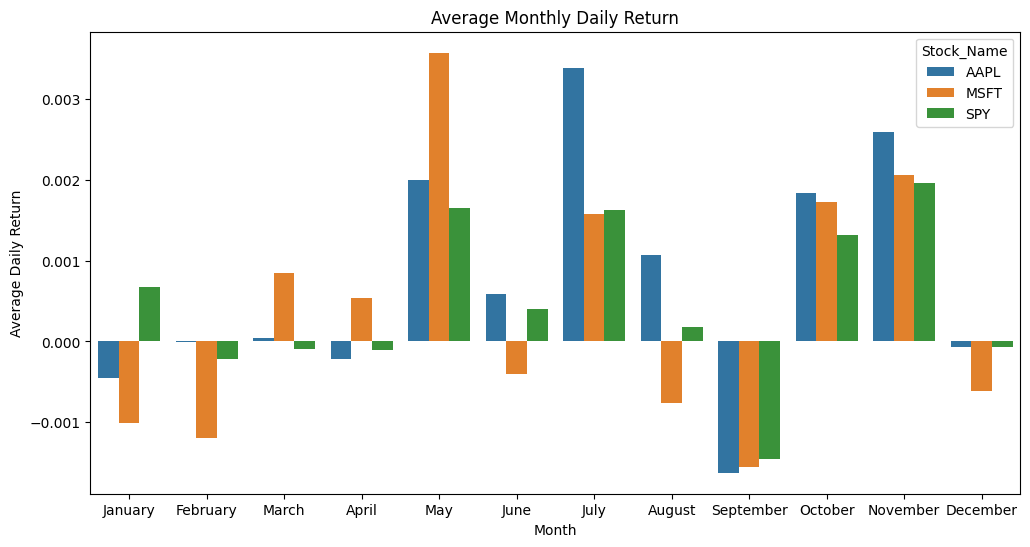

In [62]:
monthly_return = (
    df.groupby(['Month','Stock_Name'])['Daily_Return']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=monthly_return,
    x='Month',
    y='Daily_Return',
    hue='Stock_Name'
)

plt.title("Average Monthly Daily Return")
plt.xlabel("Month")
plt.ylabel("Average Daily Return")
plt.show()

In [63]:
# chart shows the average daily return for each month.
# Positive values indicate months with average gains, while negative values indicate months with average losses.

#Monthly average returns help identify stronger and weaker periods of stock performance throughout the year

In [64]:
best_month = (
    monthly_close
    .sort_values('Close', ascending=False)
)

best_month.head(10)

,Month,Stock_Name,Close
17,June,SPY,541.030686
14,May,SPY,528.554434
5,February,SPY,527.578750
35,December,SPY,523.034151
2,January,SPY,522.690198
11,April,SPY,520.125146
8,March,SPY,513.852110
32,November,SPY,509.339510
29,October,SPY,502.070000
20,July,SPY,500.029905
